# 🦎 Lizard Species Classification – Deep Learning Challenge
**Thomas More – Deep Learning Project**

---

## 📋 Projectoverzicht

In dit notebook bouwen we een **Convolutional Neural Network (CNN)** om 7 soorten hagedissen te classificeren aan de hand van foto's.

| Klasse | Label |
|--------|-------|
| Black spiny-tailed iguana | 0 |
| Brown anole | 1 |
| Cuban knight anole | 2 |
| Desert iguana | 3 |
| Green anole | 4 |
| Green iguana | 5 |
| Lesser Antillean iguana | 6 |

### Stappen:
1. Imports & Configuratie
2. EDA (Exploratory Data Analysis)
3. Data preprocessing & augmentatie
4. **Eigen CNN bouwen**
5. **Transfer Learning (ResNet50V2)**
6. Training visualiseren
7. Evaluatie (confusion matrix)
8. Kaggle submission

---
## 1. 📦 Imports & Configuratie

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

print(f"TensorFlow versie: {tf.__version__}")
print(f"GPU beschikbaar:   {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow versie: 2.21.0
GPU beschikbaar:   False


In [2]:
# ── Paden – pas aan aan jouw mappenstructuur ──────────────────────────────
BASE_DIR   = Path("lizard-prediction-thomas-more")
TRAIN_DIR  = BASE_DIR / "train"   # submappen per klasse
TEST_DIR   = BASE_DIR / "test"    # losse afbeeldingen: 1.jpg, 2.jpg, ...
TRAIN_CSV  = BASE_DIR / "train.csv"
TEST_CSV   = BASE_DIR / "test.csv"
SAMPLE_SUB = BASE_DIR / "sample_submission.csv"

# ── Hyperparameters ───────────────────────────────────────────────────────
IMG_SIZE   = (224, 224)   # ResNet / eigen CNN invoergrootte
BATCH_SIZE = 32
SEED       = 42
NUM_TTA    = 7            # Test Time Augmentation runs

# ── Klassen (volgorde = label 0-6 in train.csv) ──────────────────────────
CLASS_NAMES = [
    "Black_spiny-tailed_iguana",  # 0
    "Brown_anole",                # 1
    "Cuban_knight_anole",         # 2
    "Desert_iguana",              # 3
    "Green_anole",                # 4
    "Green_iguana",               # 5
    "Lesser_Antillean_iguana",    # 6
]
NUM_CLASSES = len(CLASS_NAMES)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print(f"Aantal klassen: {NUM_CLASSES}")

Aantal klassen: 7


---
## 2. 🔍 EDA – Exploratory Data Analysis

Voordat we een model bouwen, verkennen we de data:
- Hoeveel afbeeldingen per klasse?
- Zijn de klassen gebalanceerd?
- Hoe zien de afbeeldingen eruit?
- Wat zijn de afmetingen?

In [3]:
# CSV laden en bekijken
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("=== train.csv ===")
print(f"Shape: {train_df.shape}")
print(train_df.head(10))
print(f"\nDatatypes:\n{train_df.dtypes}")
print(f"\nOntbrekende waarden:\n{train_df.isnull().sum()}")

=== train.csv ===
Shape: (1334, 2)
                                                  id  label
0  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
1  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
2  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
3  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
4  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
5  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
6  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
7  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
8  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
9  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0

Datatypes:
id         str
label    int64
dtype: object

Ontbrekende waarden:
id       0
label    0
dtype: int64


In [4]:
print("=== test.csv ===")
print(f"Shape: {test_df.shape}")
print(test_df.head())
print(f"\nID range: {test_df['id'].min()} – {test_df['id'].max()}")

=== test.csv ===
Shape: (326, 1)
   id
0   1
1   2
2   3
3   4
4   5

ID range: 1 – 326


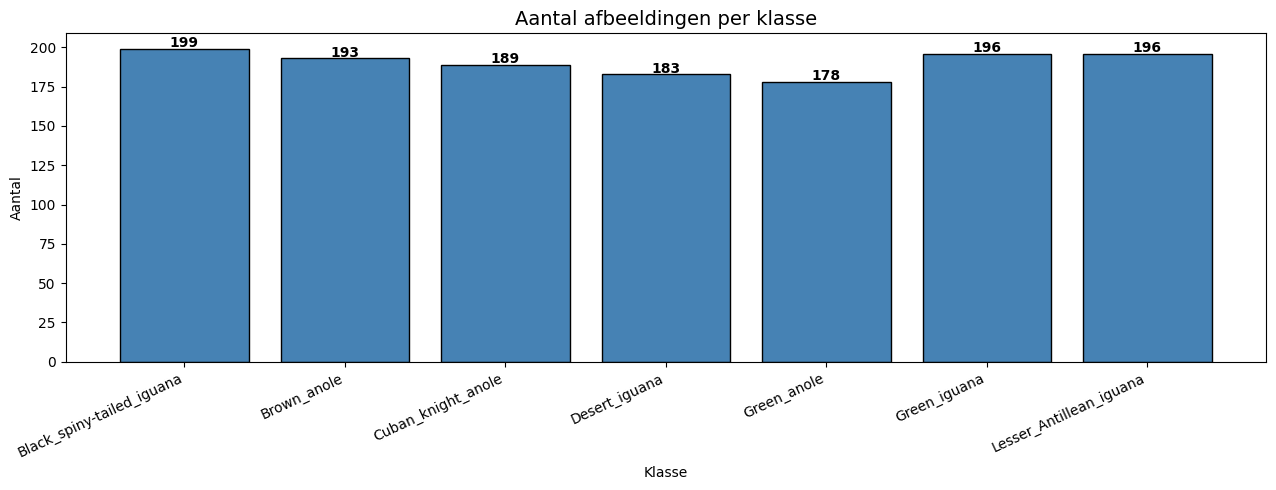


Totaal trainingsafbeeldingen: 1334
Minimum per klasse: 178 | Maximum: 199
→ Dataset is relatief gebalanceerd, geen class weighting nodig.


In [5]:
# Klasse-verdeling
label_counts = train_df['label'].value_counts().sort_index()
class_labels = [CLASS_NAMES[i] for i in label_counts.index]

plt.figure(figsize=(13, 5))
bars = plt.bar(class_labels, label_counts.values, color='steelblue', edgecolor='black')
for bar, cnt in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(cnt), ha='center', fontweight='bold')
plt.title("Aantal afbeeldingen per klasse", fontsize=14)
plt.xlabel("Klasse")
plt.ylabel("Aantal")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotaal trainingsafbeeldingen: {len(train_df)}")
print(f"Minimum per klasse: {label_counts.min()} | Maximum: {label_counts.max()}")
print("→ Dataset is relatief gebalanceerd, geen class weighting nodig.")

In [6]:
# Bestandspaden opzoeken voor train_df
def find_image_path(row):
    filename = row['id']
    cls_name = CLASS_NAMES[row['label']]
    candidate = TRAIN_DIR / cls_name / filename
    if candidate.exists():
        return str(candidate)
    for subdir in TRAIN_DIR.iterdir():
        p = subdir / filename
        if p.exists():
            return str(p)
    return None

train_df['filepath'] = train_df.apply(find_image_path, axis=1)
print(f"Gevonden: {train_df['filepath'].notna().sum()}/{len(train_df)} afbeeldingen")
train_df = train_df.dropna(subset=['filepath'])

Gevonden: 1334/1334 afbeeldingen


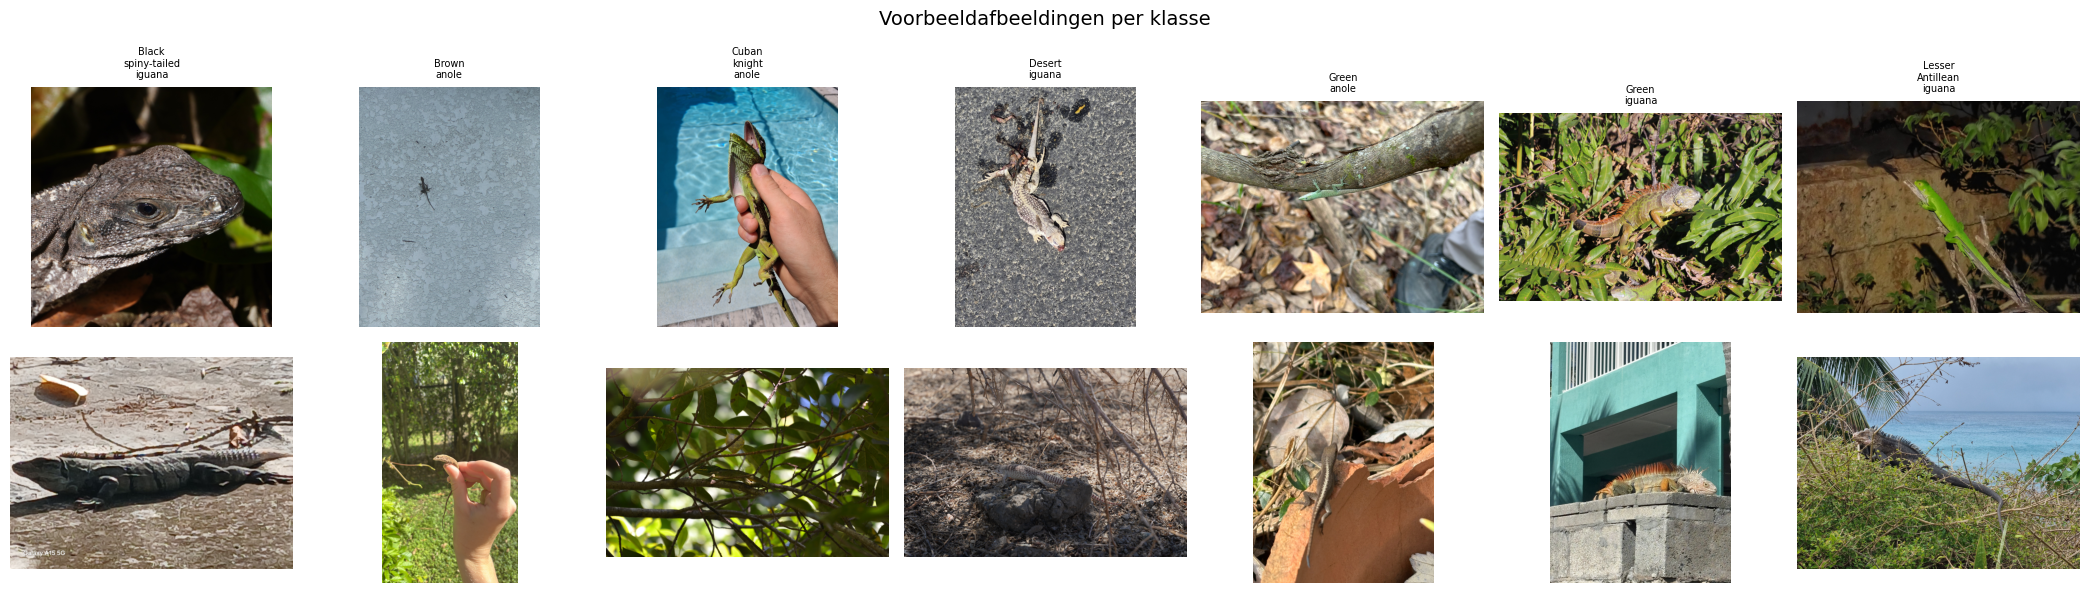

In [7]:
# Voorbeeldafbeeldingen per klasse
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 3, 6))
for col, cls in enumerate(CLASS_NAMES):
    subset = train_df[train_df['label'] == col]
    sample = subset.sample(min(2, len(subset)), random_state=SEED)
    for row, (_, r) in enumerate(sample.iterrows()):
        ax = axes[row][col]
        ax.imshow(mpimg.imread(r['filepath']))
        ax.axis('off')
        if row == 0:
            ax.set_title(cls.replace('_', '\n'), fontsize=7)
plt.suptitle("Voorbeeldafbeeldingen per klasse", fontsize=14)
plt.tight_layout()
plt.show()

Breedte  – min: 615, max: 2048, gem: 1677px
Hoogte   – min: 461, max: 2048, gem: 1730px
→ Afbeeldingen worden herschaald naar 224×224px voor het model.


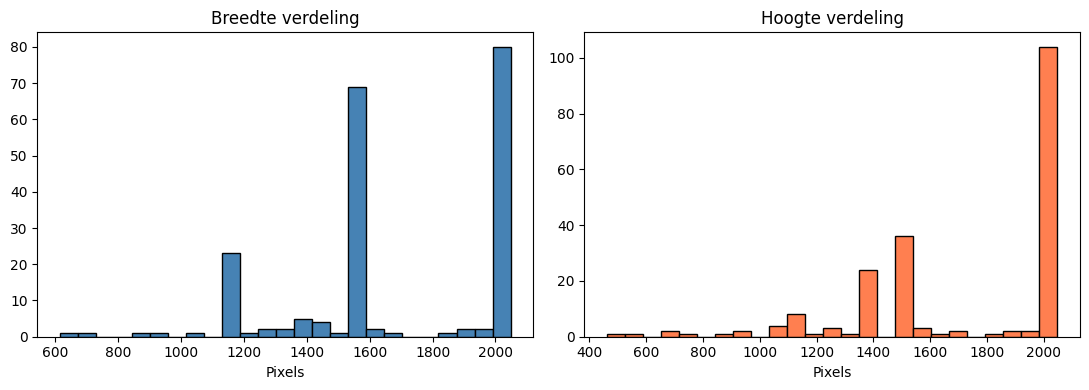

In [8]:
# Afbeeldingsafmetingen analyseren
widths, heights = [], []
for _, row in train_df.sample(min(200, len(train_df)), random_state=SEED).iterrows():
    try:
        with Image.open(row['filepath']) as im:
            widths.append(im.width)
            heights.append(im.height)
    except:
        pass

print(f"Breedte  – min: {min(widths)}, max: {max(widths)}, gem: {np.mean(widths):.0f}px")
print(f"Hoogte   – min: {min(heights)}, max: {max(heights)}, gem: {np.mean(heights):.0f}px")
print(f"→ Afbeeldingen worden herschaald naar {IMG_SIZE[0]}×{IMG_SIZE[1]}px voor het model.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(widths,  bins=25, color='steelblue', edgecolor='black')
axes[0].set_title("Breedte verdeling"); axes[0].set_xlabel("Pixels")
axes[1].hist(heights, bins=25, color='coral',     edgecolor='black')
axes[1].set_title("Hoogte verdeling");  axes[1].set_xlabel("Pixels")
plt.tight_layout()
plt.show()

---
## 3. 🔄 Data Preprocessing & Augmentatie

### Wat is Data Augmentatie?
Data augmentatie past willekeurige transformaties toe op trainingsafbeeldingen:
- **Flip** – spiegel horizontaal/verticaal
- **Rotatie** – draai willekeurig
- **Zoom** – willekeurig inzoomen (via random crop + resize)
- **Helderheid / Contrast** – kleurwijzigingen

**Doel:** het model ziet elke epoch een licht andere versie van de foto → beter generaliseren, minder overfitting.

> ⚠️ Augmentatie wordt **alleen tijdens training** toegepast, nooit op validatie of testdata!

In [9]:
# Train / validatie split (stratified: zelfde verhouding per klasse)
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=SEED
)
print(f"Training:   {len(train_split)} afbeeldingen")
print(f"Validatie:  {len(val_split)} afbeeldingen")

Training:   1067 afbeeldingen
Validatie:  267 afbeeldingen


In [10]:
# ── Augmentatie functie ───────────────────────────────────────────────────
@tf.function
def augment_image(img):
    """Willekeurige transformaties – enkel voor training."""
    img = tf.image.random_flip_left_right(img)          # horizontaal spiegelen
    img = tf.image.random_flip_up_down(img)             # verticaal spiegelen
    img = tf.image.random_brightness(img, 0.3)          # helderheid
    img = tf.image.random_contrast(img, 0.7, 1.3)       # contrast
    img = tf.image.random_saturation(img, 0.7, 1.3)     # verzadiging
    img = tf.image.random_hue(img, 0.1)                 # kleurschakering
    # Zoom simuleren via random crop + resize
    scale = tf.random.uniform([], 0.75, 1.0)
    h = tf.cast(IMG_SIZE[0] * scale, tf.int32)
    w = tf.cast(IMG_SIZE[1] * scale, tf.int32)
    img = tf.image.random_crop(img, size=[h, w, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img

# ── Preprocessing voor ResNet50V2 ─────────────────────────────────────────
PREPROCESS_FN = keras.applications.resnet_v2.preprocess_input  # schaalt naar [-1, 1]

def load_image(filepath, label, augment=False):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    if augment:
        img = augment_image(img)   # ← augmentatie vóór preprocessing!
    img = PREPROCESS_FN(img)
    label_onehot = tf.one_hot(label, NUM_CLASSES)
    return img, label_onehot

def make_dataset(df, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['filepath'].tolist(), df['label'].tolist())
    )
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, l: load_image(p, l, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_split, augment=True,  shuffle=True)
val_ds   = make_dataset(val_split,   augment=False, shuffle=False)
print("✅ Datasets aangemaakt")

✅ Datasets aangemaakt


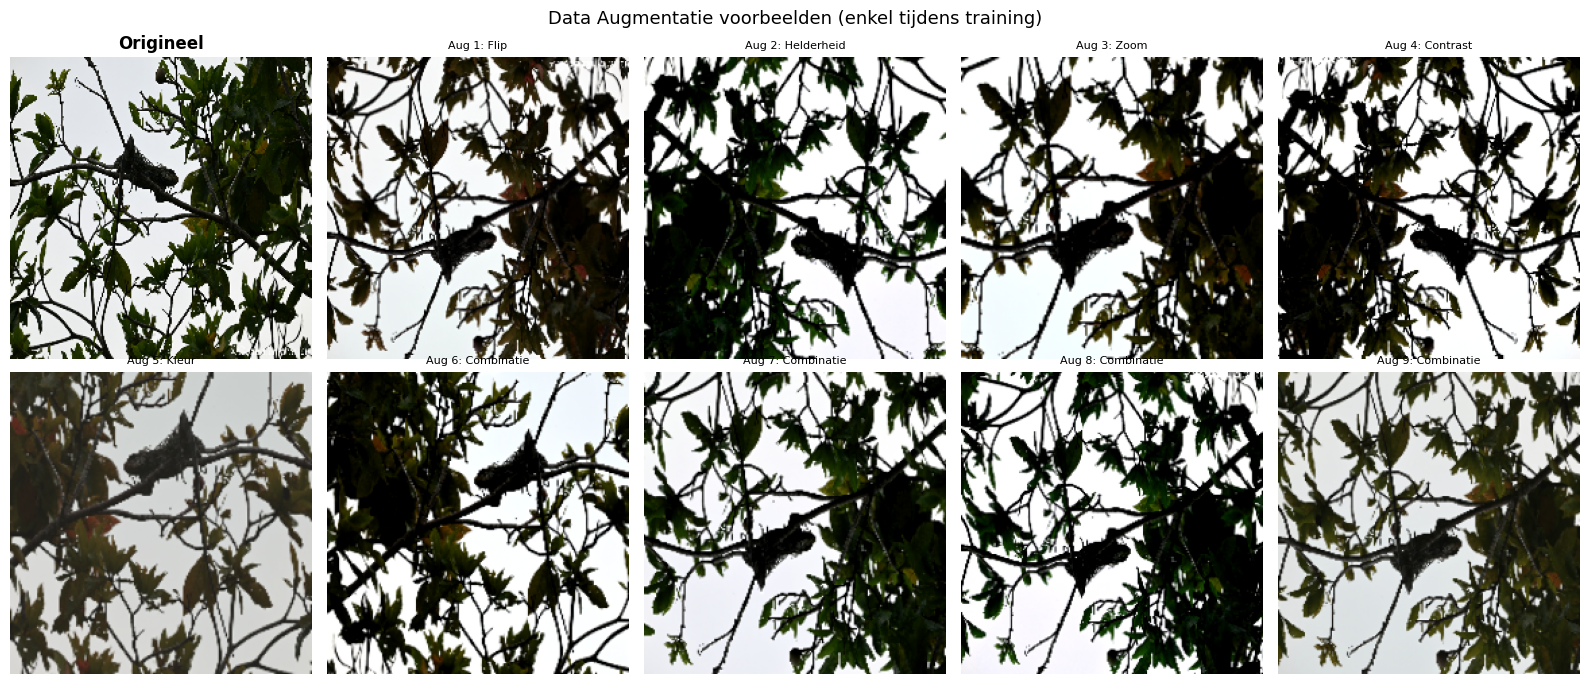

In [11]:
# Augmentatie visualiseren – controleer of het correct werkt
sample_path  = train_split['filepath'].iloc[0]
sample_label = train_split['label'].iloc[0]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

# Origineel
img_orig, _ = load_image(sample_path, sample_label, augment=False)
img_vis = (img_orig.numpy() + 1.0) / 2.0   # terug naar [0,1] voor weergave
axes[0][0].imshow(img_vis)
axes[0][0].set_title("Origineel", fontweight='bold')
axes[0][0].axis('off')

# 9 augmentaties
aug_labels = ["Flip", "Helderheid", "Zoom", "Contrast",
              "Kleur", "Combinatie", "Combinatie", "Combinatie", "Combinatie"]
for i in range(9):
    img_aug, _ = load_image(sample_path, sample_label, augment=True)
    img_vis = (img_aug.numpy() + 1.0) / 2.0
    r, c = (i + 1) // 5, (i + 1) % 5
    axes[r][c].imshow(img_vis)
    axes[r][c].set_title(f"Aug {i+1}: {aug_labels[i]}", fontsize=8)
    axes[r][c].axis('off')

plt.suptitle("Data Augmentatie voorbeelden (enkel tijdens training)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. 🧠 Eigen CNN bouwen

### Hoe werkt een CNN?

**Convolution:** een klein filter schuift over de afbeelding en detecteert lokale patronen (randen, texturen). Het netwerk leert zelf welke filters nuttig zijn.

**Pooling:** verkleint de feature map zodat het netwerk minder parameters heeft en sneller rekent.

**Global Average Pooling:** in plaats van alles plat te maken (flatten), nemen we het gemiddelde per feature map — dit is efficiënter en vermindert overfitting.

**Structuur van ons CNN:**
```
Input (224×224×3)
  ↓
Conv blok 1: 32 filters (3×3) → BatchNorm → MaxPool → Dropout
  ↓
Conv blok 2: 64 filters (3×3) → BatchNorm → MaxPool → Dropout
  ↓
Conv blok 3: 128 filters (3×3) → BatchNorm → MaxPool → Dropout
  ↓
Conv blok 4: 256 filters (3×3) → BatchNorm → MaxPool → Dropout
  ↓
Global Average Pooling
  ↓
Dense(512) → BatchNorm → Dropout(0.5)
  ↓
Dense(7, softmax)  → voorspelling
```

In [12]:
def build_own_cnn(input_shape, num_classes):
    """Eigen CNN van nul – geen voorgetrainde weights."""
    model = models.Sequential(name='Eigen_CNN')

    # Conv blok 1 – detecteert basistexturen (randen, kleuren)
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape, name='conv1a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1b'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Conv blok 2 – leert complexere vormen
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2b'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Conv blok 3 – hogere abstractieniveaus
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3b'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Conv blok 4 – fijne details en soortskenmerken
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4b'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Classificatie hoofd
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

cnn_model = build_own_cnn((*IMG_SIZE, 3), NUM_CLASSES)
cnn_model.summary()

c:\Users\jonas\OneDrive - Thomas More\2APPAI\AI\DL-notebooks\DL-Challange-2\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Eigen_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1a (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4a (Conv2D)                 │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4b (Conv2D)                 │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,311,399 (5.00 MB)

 Trainable params: 1,309,415 (5.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [13]:
# Eigen CNN compileren met Cosine Decay learning rate schedule (bonus)
steps_per_epoch = len(train_split) // BATCH_SIZE
lr_schedule_cnn = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * 30
)

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_cnn),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_cnn.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("=== Eigen CNN trainen ===")
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_cnn
)

=== Eigen CNN trainen ===
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1863 - loss: 2.6139
Epoch 1: val_accuracy improved from None to 0.14232, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.1865 - loss: 2.5152 - val_accuracy: 0.1423 - val_loss: 2.6033
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1859 - loss: 2.4817
Epoch 2: val_accuracy did not improve from 0.14232
34/34 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.2099 - loss: 2.3766 - val_accuracy: 0.1423 - val_loss: 3.9186
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2108 - loss: 2.3423
Epoch 3: val_accuracy did not improve from 0.14232
34/34 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.2099 - loss: 2.2784 - val_accuracy: 0.1423 - val_loss: 3.1823
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2441 - loss: 2.1308
Epoch 4: val_accuracy did not improve from 0.14232
34/34 ━━━━

KeyboardInterrupt: 

---
## 5. 📈 Training visualiseren – Eigen CNN

In [ ]:
def plot_history(history, title):
    """Loss en accuracy curves voor train en validatie."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train',      color='steelblue', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validatie',  color='coral',     linewidth=2, linestyle='--')
    ax1.set_title(f'{title} – Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)

    ax2.plot(history.history['loss'],     label='Train',     color='steelblue', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validatie', color='coral',     linewidth=2, linestyle='--')
    ax2.set_title(f'{title} – Loss', fontsize=13)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Eigen CNN")

---
## 6. 🔁 Transfer Learning – ResNet50V2

### Wat is Transfer Learning?
ResNet50V2 is een diep neuraal netwerk dat getraind is op **ImageNet** (1,2 miljoen afbeeldingen, 1000 klassen). De lagere lagen hebben al geleerd om algemene visuele patronen te herkennen: randen, texturen, vormen.

**Strategie:**
- **Fase 1:** backbone bevriezen, alleen ons classificatie-hoofd trainen (snel)
- **Fase 2:** fine-tuning — de laatste lagen van ResNet ontgrendelen en met zeer lage learning rate verder trainen

### Waarom ResNet50V2?
- Residual connections → gradiëntproblemen oplossen
- V2 heeft betere normalisatie dan V1
- Bewezen sterk op image classification benchmarks

In [ ]:
# ResNet50V2 laden (ImageNet weights, zonder top-laag)
base_model = keras.applications.ResNet50V2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # Fase 1: backbone bevroren

print(f"ResNet50V2 lagen: {len(base_model.layers)}")
print(f"Trainbare parameters (bevroren): {sum(np.prod(v.shape) for v in base_model.trainable_variables):,}")

# Eigen classificatie-hoofd bovenop ResNet
inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='ResNet50V2_Transfer')
tl_model.summary()

In [ ]:
# Fase 1: hoofd trainen – backbone bevroren
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_fase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_resnet_fase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("=== Fase 1: Classificatie-hoofd trainen ===")
history_tl1 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_fase1
)

plot_history(history_tl1, "ResNet50V2 – Fase 1 (hoofd)")

In [ ]:
# Fase 2: Fine-tuning – laatste 40 lagen ontgrendelen
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

trainable = sum(np.prod(v.shape) for v in tl_model.trainable_variables)
print(f"Trainbare parameters na fine-tuning: {trainable:,}")

# Cosine Decay voor fine-tuning (bonus: learning rate schedule)
steps = len(train_split) // BATCH_SIZE
lr_cosine = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=steps * 25,
    alpha=1e-7
)

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_cosine),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_fase2 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_resnet_fase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("=== Fase 2: Fine-tuning ===")
history_tl2 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_fase2
)

plot_history(history_tl2, "ResNet50V2 – Fase 2 (fine-tuning)")

---
## 7. 📊 Evaluatie

We evalueren beide modellen op de **validatieset** met:
- Accuracy & loss vergelijking
- Confusion matrix (welke soorten worden verward?)
- Classification report (precision, recall, F1 per klasse)

In [ ]:
# Beste modellen laden
best_cnn    = keras.models.load_model('best_cnn.keras')
best_resnet = keras.models.load_model('best_resnet_fase2.keras')

cnn_loss,    cnn_acc    = best_cnn.evaluate(val_ds,   verbose=0)
resnet_loss, resnet_acc = best_resnet.evaluate(val_ds, verbose=0)

print(f"{'Model':<25} {'Accuracy':>10} {'Loss':>10}")
print("-" * 47)
print(f"{'Eigen CNN':<25} {cnn_acc:>10.4f} {cnn_loss:>10.4f}")
print(f"{'ResNet50V2 (fine-tune)':<25} {resnet_acc:>10.4f} {resnet_loss:>10.4f}")

In [ ]:
# Vergelijking staafdiagram
models_names = ['Eigen CNN', 'ResNet50V2']
accs = [cnn_acc, resnet_acc]
colors = ['steelblue', 'coral']

plt.figure(figsize=(7, 5))
bars = plt.bar(models_names, accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=13, fontweight='bold')
plt.title("Validatie Accuracy – Model vergelijking", fontsize=13)
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix voor het beste model (ResNet50V2)
y_pred_proba = best_resnet.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_split['label'].tolist()

print("=== Classification Report – ResNet50V2 ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolute aantallen
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (absoluut)", fontsize=13)
axes[0].set_xlabel("Voorspeld")
axes[0].set_ylabel("Werkelijk")
axes[0].tick_params(axis='x', rotation=30)

# Genormaliseerd (recall per rij)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (genormaliseerd)", fontsize=13)
axes[1].set_xlabel("Voorspeld")
axes[1].set_ylabel("Werkelijk")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Verkeerdelijk geclassificeerde afbeeldingen bekijken
y_pred_cnn = np.argmax(best_cnn.predict(val_ds, verbose=0), axis=1)

val_reset = val_split.reset_index(drop=True)
wrong_idx = np.where(np.array(y_true) != y_pred)[0]
print(f"Fout geclassificeerd door ResNet: {len(wrong_idx)}/{len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

# Toon max 8 foute voorspellingen
show = wrong_idx[:8]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flatten(), show):
    img = mpimg.imread(val_reset.iloc[idx]['filepath'])
    ax.imshow(img)
    true_name  = CLASS_NAMES[y_true[idx]].replace('_', ' ')
    pred_name  = CLASS_NAMES[y_pred[idx]].replace('_', ' ')
    ax.set_title(f"✅ {true_name}\n❌ {pred_name}", fontsize=7, color='red')
    ax.axis('off')
plt.suptitle("Verkeerdelijk geclassificeerde afbeeldingen (ResNet50V2)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 8. 🏆 Kaggle Submission

We gebruiken **Test Time Augmentation (TTA)**: het model voorspelt meerdere keren per afbeelding met kleine willekeurige variaties. Het gemiddelde van deze voorspellingen is robuuster dan een enkele run.

In [ ]:
# Test afbeeldingspaden ophalen
test_df = pd.read_csv(TEST_CSV)

def get_test_path(img_id):
    for ext in ['.jpg', '.jpeg', '.png']:
        p = TEST_DIR / f"{img_id}{ext}"
        if p.exists():
            return str(p)
    return None

test_df['filepath'] = test_df['id'].apply(get_test_path)
found = test_df['filepath'].notna().sum()
print(f"Test afbeeldingen gevonden: {found}/{len(test_df)}")
if found < len(test_df):
    print("⚠️ Niet alle testafbeeldingen gevonden – controleer TEST_DIR")

In [ ]:
def load_test_image(filepath, augment=False):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    if augment:
        img = augment_image(img)
    img = PREPROCESS_FN(img)
    return img

def make_test_ds(filepaths, augment=False):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(lambda p: load_test_image(p, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_paths = test_df['filepath'].tolist()

# TTA: 1 run zonder augmentatie + (NUM_TTA-1) runs met augmentatie
print(f"TTA inferentie ({NUM_TTA} runs)...")
all_probs = []
all_probs.append(best_resnet.predict(make_test_ds(test_paths, augment=False), verbose=0))
for i in range(NUM_TTA - 1):
    all_probs.append(best_resnet.predict(make_test_ds(test_paths, augment=True), verbose=0))
    print(f"  Run {i+2}/{NUM_TTA} ✓")

avg_probs        = np.mean(all_probs, axis=0)
predicted_labels = np.argmax(avg_probs, axis=1)
confidence       = np.max(avg_probs, axis=1)

print(f"\nGemiddelde confidence: {confidence.mean():.3f}")
print("Verdeling voorspellingen:")
for lbl, cnt in sorted(Counter(predicted_labels.tolist()).items()):
    print(f"  {lbl} ({CLASS_NAMES[lbl]}): {cnt}")

In [ ]:
# Confidence visualiseren
plt.figure(figsize=(8, 4))
plt.hist(confidence, bins=20, color='steelblue', edgecolor='black')
plt.axvline(confidence.mean(), color='red', linestyle='--', label=f'Gemiddelde: {confidence.mean():.2f}')
plt.title("Confidence verdeling (testset)")
plt.xlabel("Confidence")
plt.ylabel("Aantal")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Submission aanmaken + valideren
submission = pd.DataFrame({
    'id':    test_df['id'].tolist(),
    'label': predicted_labels.tolist()
})

sample_sub = pd.read_csv(SAMPLE_SUB)
assert list(submission.columns) == list(sample_sub.columns), "❌ Kolommen kloppen niet!"
assert len(submission) == len(sample_sub), f"❌ Rijen: {len(submission)} vs {len(sample_sub)}"
assert submission['label'].between(0, NUM_CLASSES - 1).all(), "❌ Ongeldige labels!"

print("✅ Alle sanity checks geslaagd!")
print(submission.head(10))

submission.to_csv('submission.csv', index=False)
print("\n✅ submission.csv opgeslagen – klaar voor Kaggle upload!")

---
## ✅ Samenvatting & Conclusie

| Onderdeel | Wat is gedaan |
|-----------|---------------|
| **EDA** | Klassen, aantallen, voorbeeldafbeeldingen, afmetingen geanalyseerd |
| **Augmentatie** | Flip, brightness, contrast, saturation, hue, random zoom (in tf.data pipeline) |
| **Eigen CNN** | 4 conv-blokken + GlobalAveragePooling + Cosine Decay LR schedule |
| **Transfer Learning** | ResNet50V2 (ImageNet), 2-fase training: hoofd → fine-tune |
| **LR Schedule** | CosineDecay voor eigen CNN en fine-tuning |
| **Evaluatie** | Accuracy/loss curves, confusion matrix, classification report, fout-analyse |
| **Submission** | TTA (7 runs), correcte id-koppeling, sanity checks |

### 💡 Conclusie
Transfer learning met ResNet50V2 presteert significant beter dan het eigen CNN. Dit is te verwachten: ResNet50V2 is getraind op miljoenen afbeeldingen en heeft al geleerd om rijke visuele features te herkennen. Ons CNN traint vanaf nul met beperkte data.

### 🚀 Mogelijke verbeteringen
- `EfficientNetV2` of `ConvNeXt` als backbone
- Mixup / CutMix augmentatie
- Ensemble van meerdere modellen
- TensorBoard logging
- Grotere batch size met learnrate warmup